In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

⏳ กำลังโหลดข้อมูลผลการทำนาย...


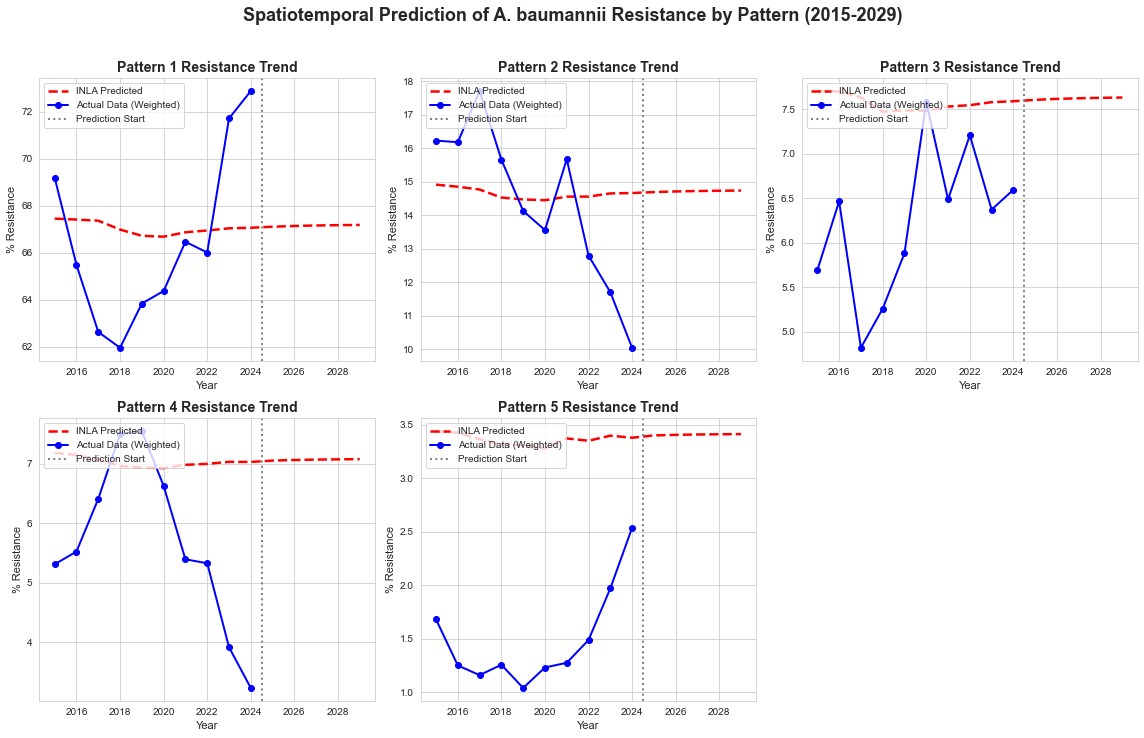

In [6]:
# 1. โหลดข้อมูล
print("⏳ กำลังโหลดข้อมูลผลการทำนาย...")
df = pd.read_csv("all_historical_and_predicted_results.csv")

# 2. จัดการปีให้ต่อเนื่องกัน (อดีต 2015-2024 + อนาคต 2025-2029)
max_history_year = df['year'].max(skipna=True)

df['plot_year'] = df.apply(
    lambda x: x['year'] if pd.isna(x['future_year']) else max_history_year + x['future_year'], 
    axis=1
)

# 3. 🌟 จุดที่แก้ไข: คำนวณค่าเฉลี่ยระดับประเทศแบบ Weighted Average 🌟
trend_data = df.groupby(['mdr_id_numeric', 'plot_year']).agg(
    sum_pattern=('pattern_count', 'sum'),                  # ผลรวมจำนวนเคสที่ดื้อยา
    sum_total=('total_rows_in_region_month', 'sum'),       # ผลรวมจำนวนเคสที่ตรวจทั้งหมด
    predicted_pct=('predicted_percent', 'mean')            # ค่าเฉลี่ยผลทำนายจาก INLA
).reset_index()

# สร้างคอลัมน์ actual_pct จากสูตร Weighted Average
trend_data['actual_pct'] = (trend_data['sum_pattern'] / trend_data['sum_total']) * 100

# 4. เริ่มวาดกราฟ
patterns = sorted(trend_data['mdr_id_numeric'].dropna().unique())
n_patterns = len(patterns)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten() 

sns.set_style("whitegrid")

for i, p_id in enumerate(patterns):
    ax = axes[i]
    subset = trend_data[trend_data['mdr_id_numeric'] == p_id]
    
    # แปลงเป็น Numpy Array ป้องกัน Error
    x_vals = subset['plot_year'].to_numpy()
    y_pred = subset['predicted_pct'].to_numpy()
    y_actual = subset['actual_pct'].to_numpy()
    
    # 🔴 กราฟเส้นค่าทำนายจากโมเดล
    ax.plot(x_vals, y_pred, color='red', linestyle='--', linewidth=2.5, label='INLA Predicted')
    
    # 🔵 กราฟเส้นค่าจริง (แบบ Weighted Average)
    ax.plot(x_vals, y_actual, color='blue', marker='o', markersize=6, linewidth=2, label='Actual Data (Weighted)')
    
    # 📏 ตีเส้นแนวตั้งแบ่งอดีตกับอนาคต
    ax.axvline(x=max_history_year + 0.5, color='gray', linestyle=':', linewidth=2, label='Prediction Start')
    
    # ตกแต่งกราฟย่อย
    ax.set_title(f'Pattern {int(p_id)} Resistance Trend', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('% Resistance', fontsize=11)
    
    ax.xaxis.get_major_locator().set_params(integer=True)
    ax.legend(loc='upper left')

# ลบกราฟช่องที่ 6 ที่ว่างอยู่
if n_patterns < len(axes):
    for j in range(n_patterns, len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Spatiotemporal Prediction of A. baumannii Resistance by Pattern (2015-2029)', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()